In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif



In [20]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

In [21]:
df.shape

(5110, 12)

In [22]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [23]:
df.dtypes

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [24]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [26]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [27]:
#DATA PREPROCESSINGG

In [28]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [29]:
df.duplicated().sum()

0

In [30]:
df = df.drop_duplicates()

In [31]:
df = df.drop(columns=["id"], errors="ignore")

In [32]:
df["bmi"] = df["bmi"].fillna(df["bmi"].median())

In [33]:
def find_outliers(column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print("\nColumn:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))


find_outliers("age")
find_outliers("bmi")
find_outliers("avg_glucose_level")


Column: age
Q1: 25.0
Q3: 61.0
IQR: 36.0
Lower Bound: -29.0
Upper Bound: 115.0
Number of Outliers: 0

Column: bmi
Q1: 23.8
Q3: 32.8
IQR: 8.999999999999996
Lower Bound: 10.300000000000006
Upper Bound: 46.29999999999999
Number of Outliers: 126

Column: avg_glucose_level
Q1: 77.245
Q3: 114.09
IQR: 36.845
Lower Bound: 21.977500000000006
Upper Bound: 169.35750000000002
Number of Outliers: 627


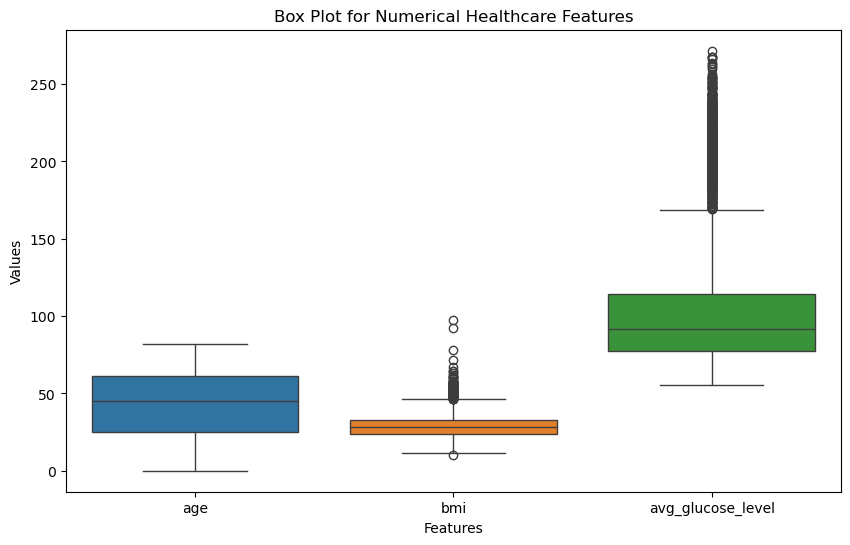

In [34]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df[["age", "bmi", "avg_glucose_level"]]
)

plt.title("Box Plot for Numerical Healthcare Features")
plt.xlabel("Features")
plt.ylabel("Values")
plt.show()



In [35]:
df.isnull().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [36]:
print(df["stroke"].value_counts())

stroke
0    4861
1     249
Name: count, dtype: int64


In [37]:
# EXPLORATORY DATA ANALYSIS (EDA)

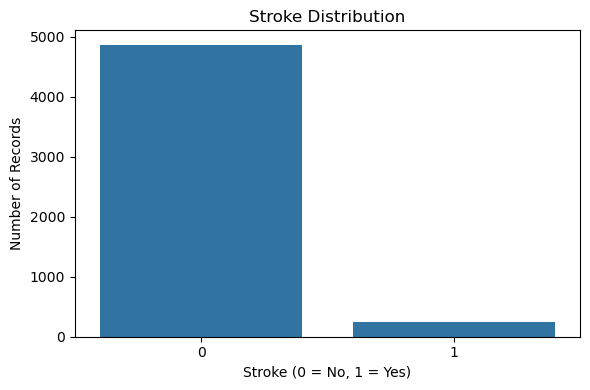

In [38]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="stroke")
plt.title("Stroke Distribution")
plt.xlabel("Stroke (0 = No, 1 = Yes)")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

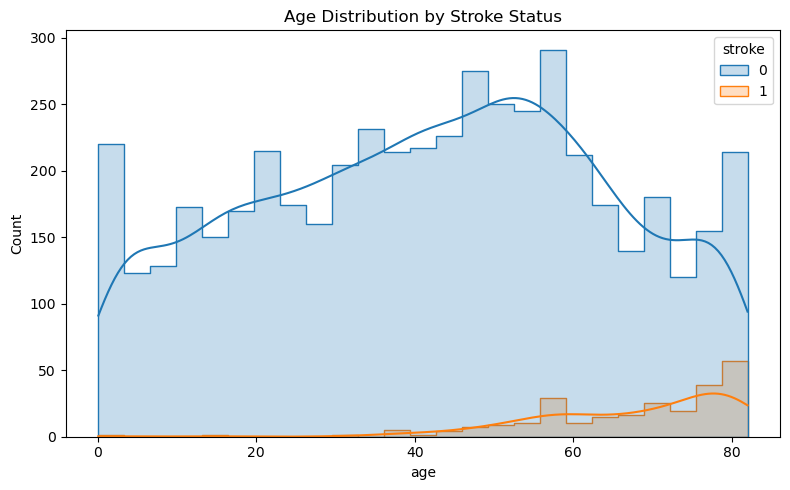

In [39]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df, x="age", hue="stroke",
    bins=25, kde=True, element="step"
)
plt.title("Age Distribution by Stroke Status")
plt.tight_layout()
plt.show()

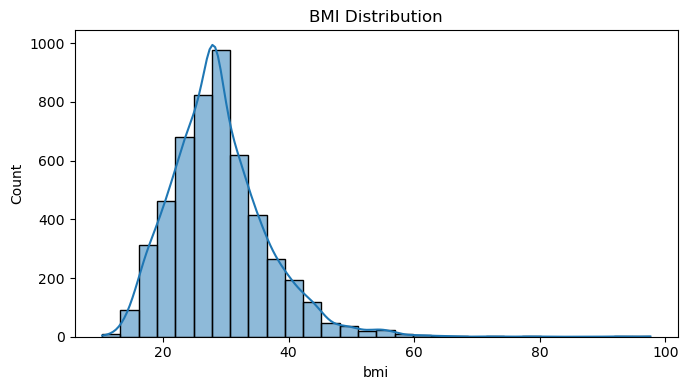

In [40]:
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="bmi", bins=30, kde=True)
plt.title("BMI Distribution")
plt.tight_layout()
plt.show()

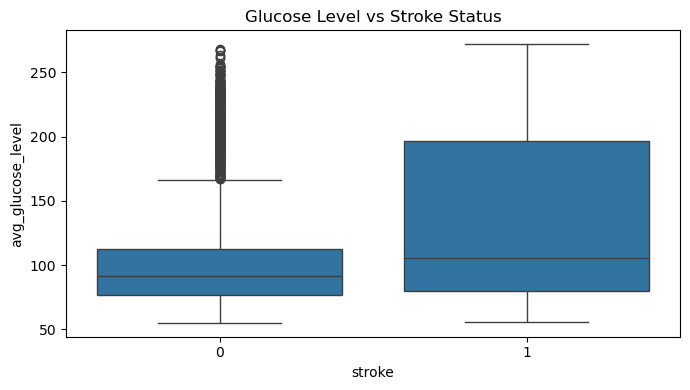

In [41]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="stroke", y="avg_glucose_level")
plt.title("Glucose Level vs Stroke Status")
plt.tight_layout()
plt.show()

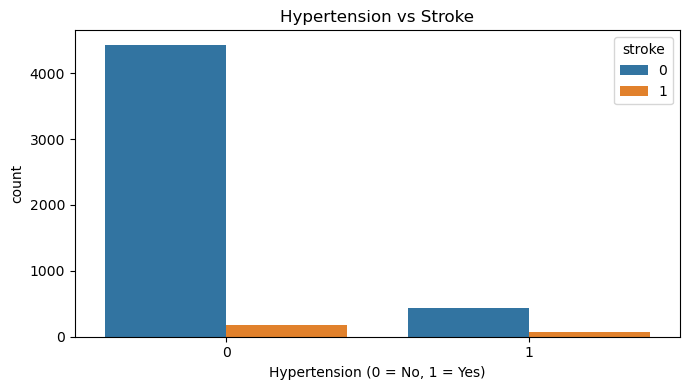

In [42]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="hypertension", hue="stroke")
plt.title("Hypertension vs Stroke")
plt.xlabel("Hypertension (0 = No, 1 = Yes)")
plt.tight_layout()
plt.show()

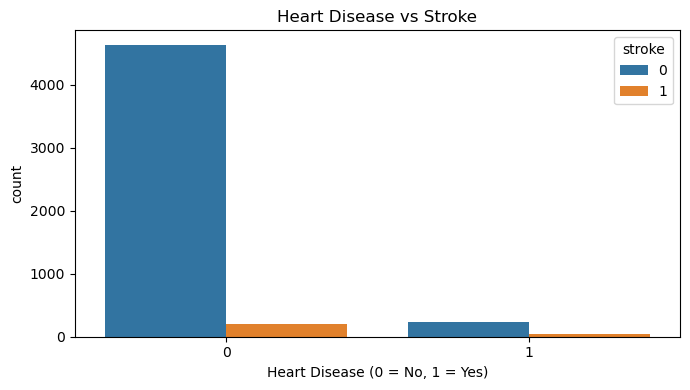

In [43]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="heart_disease", hue="stroke")
plt.title("Heart Disease vs Stroke")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.tight_layout()
plt.show()

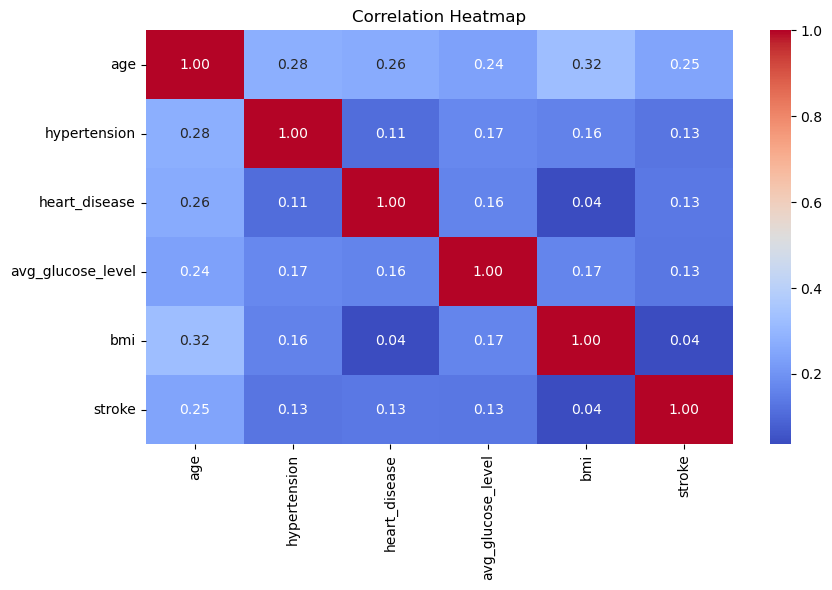

In [44]:
plt.figure(figsize=(9, 6))
numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [45]:
categorical_cols = [
    "gender", "ever_married", "work_type",
    "Residence_type", "smoking_status"
]

for col in categorical_cols:
    rates = df.groupby(col, observed=False)["stroke"].mean()
    print(f"\nStroke-record percentage by {col}:")
    print((rates * 100).round(2))


Stroke-record percentage by gender:
gender
Female    4.71
Male      5.11
Other     0.00
Name: stroke, dtype: float64

Stroke-record percentage by ever_married:
ever_married
No     1.65
Yes    6.56
Name: stroke, dtype: float64

Stroke-record percentage by work_type:
work_type
Govt_job         5.02
Never_worked     0.00
Private          5.09
Self-employed    7.94
children         0.29
Name: stroke, dtype: float64

Stroke-record percentage by Residence_type:
Residence_type
Rural    4.53
Urban    5.20
Name: stroke, dtype: float64

Stroke-record percentage by smoking_status:
smoking_status
Unknown            3.04
formerly smoked    7.91
never smoked       4.76
smokes             5.32
Name: stroke, dtype: float64


In [46]:
 # FEATURE SELECTION

In [47]:
X = df.drop(columns=["stroke"])
y = df["stroke"]

In [48]:
numeric_cols = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_cols = X.select_dtypes(
    exclude=np.number
).columns.tolist()

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [50]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


In [51]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

In [52]:
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_cols),
    ("categorical", categorical_pipeline, categorical_cols)
])

In [53]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

In [54]:
selector = SelectKBest(
    score_func=mutual_info_classif,
    k=min(10, X_train_processed.shape[1])
)

X_train_selected = selector.fit_transform(
    X_train_processed, y_train
)

X_test_selected = selector.transform(X_test_processed)

selected_features = feature_names[selector.get_support()]

print("\nSelected Features:")
for feature in selected_features:
    print(feature)


Selected Features:
numeric__age
numeric__hypertension
numeric__heart_disease
numeric__bmi
categorical__gender_Other
categorical__ever_married_No
categorical__work_type_Private
categorical__work_type_children
categorical__smoking_status_Unknown
categorical__smoking_status_formerly smoked


In [55]:
scores = pd.DataFrame({
    "Feature": feature_names,
    "Score": selector.scores_
}).sort_values("Score", ascending=False)

print("Top 10 Features:")
print(scores.head(10).to_string(index=False))

Top 10 Features:
                                    Feature    Score
                               numeric__age 0.034397
categorical__smoking_status_formerly smoked 0.010422
                               numeric__bmi 0.009679
               categorical__ever_married_No 0.008123
        categorical__smoking_status_Unknown 0.007983
                  categorical__gender_Other 0.006968
                      numeric__hypertension 0.005926
                     numeric__heart_disease 0.005460
            categorical__work_type_children 0.004735
             categorical__work_type_Private 0.004393


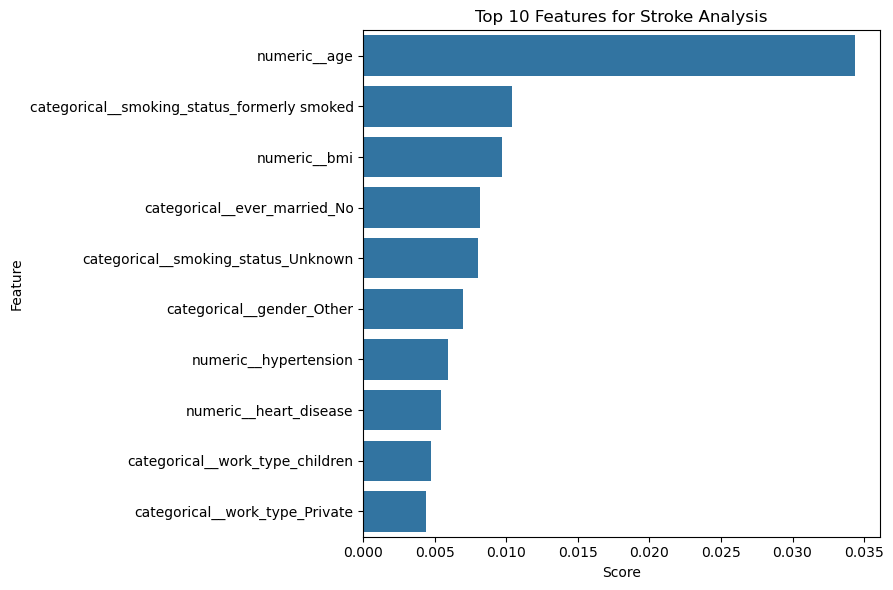

In [56]:
plt.figure(figsize=(9, 6))
sns.barplot(
    data=scores.head(10),
    x="Score",
    y="Feature"
)
plt.title("Top 10 Features for Stroke Analysis")
plt.tight_layout()
plt.show()